# Fig: rate-distortion

project = ```iP-VAE```, host = ```mach```, device = ```cuda:1```

**Motivation**: <br>


In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.convergence import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
# HIDE CODE


def _load_df(files, metric='euclidean', info_keys=None):

    info_keys = info_keys or [
        'type', 'latent_act', 'str_model',
        'seq_len', 'kl_beta',
    ]
    
    df_ratedist = collections.defaultdict(list)
    for f in tqdm(files):
        if 'softplus' in f or 'sigmoid' in f:
            continue
    
        load = np.load(pjoin(results_dir, f), allow_pickle=True).item()
        info, results = load['info'], load['results']
        
        # all iterative models were batch, epoch = (200, 300)
        # some new fits are (200, 600), skip those
        s = info.get('timestamp')
        if s is not None:
            yy, mm, dd = map(int, s.split(',')[0].split('_'))
            if (mm - 3) * 31 + dd > 25:  
                # print(info)
                continue

        # info
        for k in info_keys:
            df_ratedist[k].append(info.get(k, None))
        df_ratedist['amort'].append('amort' in f)
    
        # results
        try:
            r2 = results['r2'][-1]
            percent_zeros = results['%-zeros'][-1]
        except TypeError:
            r2 = results['r2']
            percent_zeros = results['%-zeros']
        r2_map = results.get('r2_map_final', None)
        if r2_map is None:
            r2_map = r2

        if metric == 'euclidean':
            distance = np.sqrt(
                (1 - r2) ** 2 +
                (1 - percent_zeros) ** 2
            )
            distance_map = np.sqrt(
                (1 - r2_map) ** 2 +
                (1 - percent_zeros) ** 2
            )
        elif metric == 'manhattan':
            distance = abs(1 - r2) + abs(1 - percent_zeros)
            distance_map = abs(1 - r2_map) + abs(1 - percent_zeros)
        else:
            raise NotImplementedError(metric)

        df_ratedist['%-zeros'].append(percent_zeros)
        df_ratedist['r2'].append(r2)
        df_ratedist['r2_map'].append(r2_map)
        df_ratedist['distance'].append(distance)
        df_ratedist['distance_map'].append(distance_map)
    
    df_ratedist = pd.DataFrame(df_ratedist)
    return df_ratedist
# df_ratedist.shape

## Results & Figs dir

In [3]:
pal_models = get_palette_models()

results_dir = pjoin(tmp_dir, 'results_2025-03')
figs_dir = pjoin(fig_base_dir, 'figs_2025-03', 'ratedist')

os.makedirs(results_dir, exist_ok=True)
os.makedirs(figs_dir, exist_ok=True)

len(os.listdir(results_dir)), len(os.listdir(figs_dir))

(624, 12)

## df: rate-distortion

In [4]:
files = [
    f for f in os.listdir(results_dir) if
    any(x in f for x in ('vH16', 'lca'))
]
files = sorted(files, key=alphanum_sort_key)

df_ratedist = _load_df(files)
df_ratedist.shape

100%|█████████████████████████████████████████| 175/175 [00:06<00:00, 26.76it/s]


(139, 11)

In [5]:
save_obj(
    obj=df_ratedist,
    file_name='df_ratedist',
    save_dir='/home/hadi/Dropbox/git/IterativeVAE/results',
    mode='df',
)

[PROGRESS] 'df_ratedist.df' saved at
/home/hadi/Dropbox/git/IterativeVAE/results

### main figs

In [6]:
from figures.final import fig_ratedist_box, fig_ratedist_scatter

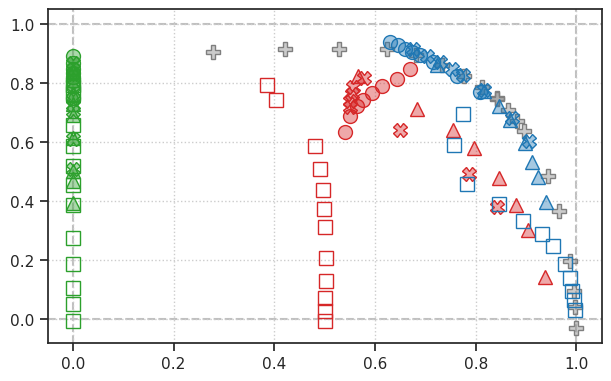

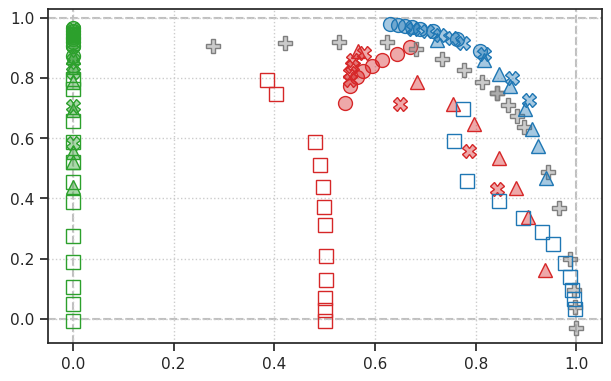

In [7]:
fig = fig_ratedist_scatter(df_ratedist, 'r2')
# save_fig('ratedist_scatter.pdf', figs_dir, fig)

fig = fig_ratedist_scatter(df_ratedist, 'r2_map')
# save_fig('ratedist_scatter_map.pdf', figs_dir, fig)

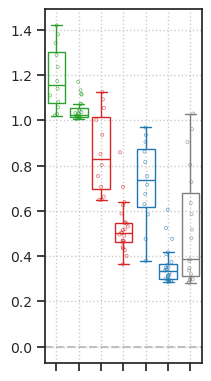

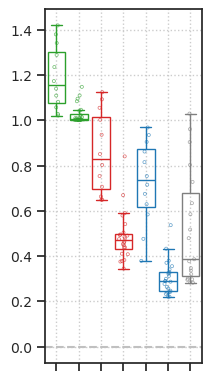

In [8]:
fig = fig_ratedist_box(df_ratedist, 'distance')
# save_fig('ratedist_box.pdf', figs_dir, fig)

fig = fig_ratedist_box(df_ratedist, 'distance_map')
# save_fig('ratedist_box_map.pdf', figs_dir, fig)

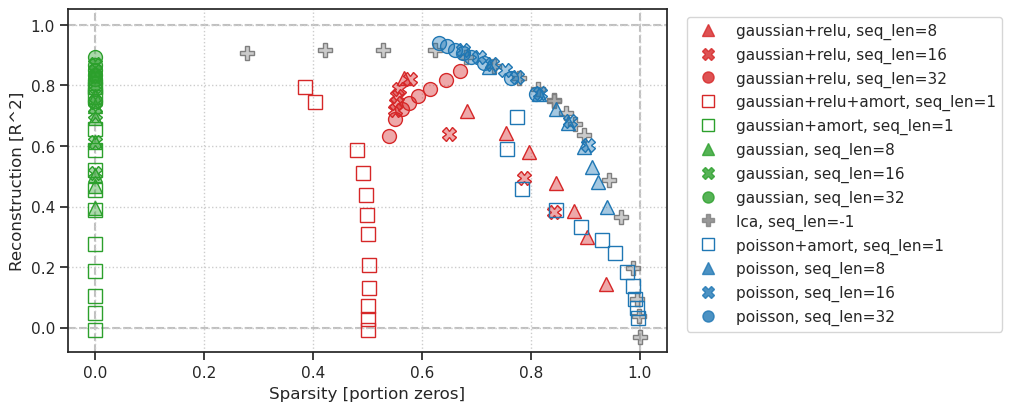

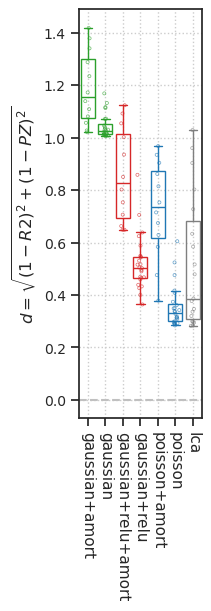

In [9]:
_ = fig_ratedist_scatter(df_ratedist, labels=True, figsize=(10, 4))
_ = fig_ratedist_box(df_ratedist, labels=True, figsize=(2, 6))

In [9]:
df_ratedist.sort_values(by='distance')

,type,latent_act,str_model,seq_len,kl_beta,amort,%-zeros,r2,r2_map,distance,distance_map
89,None,None,lca,-1,0.5,False,0.777586,0.825924,0.825924,0.282437,0.282437
91,None,None,lca,-1,0.6,False,0.813242,0.787064,0.787064,0.283231,0.283231
127,poisson,None,poisson,16,24.0,False,0.775022,0.826882,0.916790,0.283875,0.239873
126,poisson,None,poisson,16,20.0,False,0.752643,0.850000,0.931343,0.289284,0.256709
128,poisson,None,poisson,16,32.0,False,0.815906,0.776233,0.879043,0.289763,0.220275
...,...,...,...,...,...,...,...,...,...,...,...
50,gaussian,softplus,gaussian+softplus+amort,1,2.5,True,0.000000,0.089940,0.089940,1.352113,1.352113
55,gaussian,None,gaussian+amort,1,3.0,True,0.000000,0.049898,0.049898,1.379382,1.379382
56,gaussian,softplus,gaussian+softplus+amort,1,3.0,True,0.000000,0.043657,0.043657,1.383688,1.383688
59,gaussian,softplus,gaussian+softplus+amort,1,4.0,True,0.000000,-0.003781,-0.003781,1.416889,1.416889


In [13]:
df_pois = df_ratedist.loc[df_ratedist['str_model'] == 'poisson']
df_pois = df_pois.sort_values(by='distance')
df_pois[:10]

,type,latent_act,str_model,seq_len,kl_beta,amort,%-zeros,r2,r2_map,distance,distance_map
127,poisson,None,poisson,16,24.0,False,0.775022,0.826882,0.916790,0.283875,0.239873
126,poisson,None,poisson,16,20.0,False,0.752643,0.850000,0.931343,0.289284,0.256709
128,poisson,None,poisson,16,32.0,False,0.815906,0.776233,0.879043,0.289763,0.220275
116,poisson,None,poisson,8,8.0,False,0.815630,0.773012,0.857893,0.292431,0.232780
137,poisson,None,poisson,32,96.0,False,0.763749,0.825974,0.928115,0.293428,0.246946
138,poisson,None,poisson,32,128.0,False,0.809028,0.772332,0.889128,0.297158,0.220823
125,poisson,None,poisson,16,16.0,False,0.729082,0.872029,0.943479,0.299622,0.276751
115,poisson,None,poisson,8,4.0,False,0.723470,0.862664,0.924345,0.308755,0.286692
136,poisson,None,poisson,32,64.0,False,0.714716,0.872606,0.954010,0.312436,0.288968
124,poisson,None,poisson,16,12.0,False,0.703835,0.893830,0.953737,0.314620,0.299756


In [14]:
df_lca = df_ratedist.loc[df_ratedist['str_model'] == 'lca']
df_lca = df_lca.sort_values(by='distance')
df_lca[:10]

,type,latent_act,str_model,seq_len,kl_beta,amort,%-zeros,r2,r2_map,distance,distance_map
89,None,None,lca,-1,0.5,False,0.777586,0.825924,0.825924,0.282437,0.282437
91,None,None,lca,-1,0.6,False,0.813242,0.787064,0.787064,0.283231,0.283231
102,None,None,lca,-1,0.7,False,0.842296,0.750784,0.750784,0.294922,0.294922
92,None,None,lca,-1,0.7,False,0.841919,0.748479,0.748479,0.297073,0.297073
88,None,None,lca,-1,0.4,False,0.732938,0.863108,0.863108,0.300103,0.300103
93,None,None,lca,-1,0.8,False,0.863878,0.710460,0.710460,0.319941,0.319941
87,None,None,lca,-1,0.3,False,0.680564,0.895463,0.895463,0.336106,0.336106
94,None,None,lca,-1,0.9,False,0.881852,0.673800,0.673800,0.346938,0.346938
95,None,None,lca,-1,1.0,False,0.896629,0.637477,0.637477,0.376973,0.376973
86,None,None,lca,-1,0.2,False,0.622960,0.917777,0.917777,0.385902,0.385902


In [15]:
df_gausrelu = df_ratedist.loc[df_ratedist['str_model'] == 'gaussian+relu']
df_gausrelu = df_gausrelu.sort_values(by='distance')
df_gausrelu[:10]

,type,latent_act,str_model,seq_len,kl_beta,amort,%-zeros,r2,r2_map,distance,distance_map
16,gaussian,relu,gaussian+relu,32,8.0,False,0.669052,0.848624,0.903597,0.363924,0.344703
17,gaussian,relu,gaussian+relu,32,16.0,False,0.644219,0.816526,0.879536,0.400303,0.375622
1,gaussian,relu,gaussian+relu,8,8.0,False,0.683466,0.714639,0.785016,0.426174,0.382638
2,gaussian,relu,gaussian+relu,8,10.0,False,0.754928,0.643236,0.711848,0.432829,0.378275
18,gaussian,relu,gaussian+relu,32,24.0,False,0.614688,0.789922,0.858864,0.438860,0.410347
8,gaussian,relu,gaussian+relu,16,8.0,False,0.577466,0.819801,0.883695,0.459354,0.438248
3,gaussian,relu,gaussian+relu,8,12.0,False,0.797326,0.581165,0.645867,0.465295,0.408028
0,gaussian,relu,gaussian+relu,8,4.0,False,0.566947,0.824183,0.888738,0.467383,0.447118
19,gaussian,relu,gaussian+relu,32,32.0,False,0.593297,0.765940,0.839381,0.469246,0.437271
9,gaussian,relu,gaussian+relu,16,12.0,False,0.557282,0.789177,0.860462,0.490352,0.464188


In [16]:
df_gaus = df_ratedist.loc[df_ratedist['str_model'] == 'gaussian']
df_gaus = df_gaus.sort_values(by='distance')
df_gaus[:10]

,type,latent_act,str_model,seq_len,kl_beta,amort,%-zeros,r2,r2_map,distance,distance_map
76,gaussian,None,gaussian,32,8.0,False,0.000000e+00,0.893817,0.963993,1.005622,1.000648
68,gaussian,None,gaussian,16,8.0,False,0.000000e+00,0.869414,0.960687,1.008490,1.000772
77,gaussian,None,gaussian,32,16.0,False,0.000000e+00,0.868435,0.954079,1.008618,1.001054
78,gaussian,None,gaussian,32,24.0,False,0.000000e+00,0.850356,0.945303,1.011135,1.001495
69,gaussian,None,gaussian,16,12.0,False,7.567026e-08,0.849168,0.949951,1.011311,1.001252
60,gaussian,None,gaussian,8,4.0,False,0.000000e+00,0.840663,0.941861,1.012615,1.001689
79,gaussian,None,gaussian,32,32.0,False,0.000000e+00,0.835605,0.937093,1.013423,1.001977
70,gaussian,None,gaussian,16,16.0,False,0.000000e+00,0.831270,0.938064,1.014135,1.001916
80,gaussian,None,gaussian,32,40.0,False,0.000000e+00,0.822558,0.929143,1.015621,1.002507
81,gaussian,None,gaussian,32,48.0,False,0.000000e+00,0.809685,0.920141,1.017949,1.003184


## Did Gaussian+Relu change?

### Previous fit

In [6]:
df_old = df_ratedist.loc[
    # (df_ratedist['seq_len'] == 32) &
    (df_ratedist['str_model'] == 'gaussian+relu')
]
# df_gausrelu = df_gausrelu.sort_values(by='distance')
df_old

,type,latent_act,str_model,seq_len,kl_beta,amort,%-zeros,r2,r2_map,distance,distance_map
0,gaussian,relu,gaussian+relu,8,4.0,False,0.566947,0.824183,0.888738,0.467383,0.447118
1,gaussian,relu,gaussian+relu,8,8.0,False,0.683466,0.714639,0.785016,0.426174,0.382638
2,gaussian,relu,gaussian+relu,8,10.0,False,0.754928,0.643236,0.711848,0.432829,0.378275
3,gaussian,relu,gaussian+relu,8,12.0,False,0.797326,0.581165,0.645867,0.465295,0.408028
4,gaussian,relu,gaussian+relu,8,16.0,False,0.846955,0.478473,0.533971,0.543520,0.490516
5,gaussian,relu,gaussian+relu,8,20.0,False,0.879198,0.387134,0.433767,0.624659,0.578975
6,gaussian,relu,gaussian+relu,8,24.0,False,0.903012,0.301015,0.337961,0.705682,0.669106
7,gaussian,relu,gaussian+relu,8,32.0,False,0.938101,0.143649,0.161917,0.858585,0.840365
8,gaussian,relu,gaussian+relu,16,8.0,False,0.577466,0.819801,0.883695,0.459354,0.438248
9,gaussian,relu,gaussian+relu,16,12.0,False,0.557282,0.789177,0.860462,0.490352,0.464188


In [7]:
results_dir = pjoin(tmp_dir, 'results_2025-04')
files = [
    f for f in os.listdir(results_dir) if
    all(e in f for e in ['gaussian+relu', 'vH16-wht'])
]
files = sorted(files, key=alphanum_sort_key)
print(files)

[
    'gaussian+relu_<grad|lin>_vH16-wht_t-8_b-1_k-[512]_relufix_mach-665_(2025_05_15,22:42).npy',
    'gaussian+relu_<grad|lin>_vH16-wht_t-8_b-2_k-[512]_relufix_mach-665_(2025_05_15,22:42).npy',
    'gaussian+relu_<grad|lin>_vH16-wht_t-8_b-4_k-[512]_relufix_mach-665_(2025_05_15,22:42).npy',
    'gaussian+relu_<grad|lin>_vH16-wht_t-8_b-8_k-[512]_relufix_mach-665_(2025_05_15,22:42).npy',
    'gaussian+relu_<grad|lin>_vH16-wht_t-8_b-12_k-[512]_relufix_mach-665_(2025_05_16,01:33).npy',
    'gaussian+relu_<grad|lin>_vH16-wht_t-8_b-16_k-[512]_relufix_mach-665_(2025_05_16,01:33).npy',
    'gaussian+relu_<grad|lin>_vH16-wht_t-8_b-20_k-[512]_relufix_mach-665_(2025_05_16,01:33).npy',
    'gaussian+relu_<grad|lin>_vH16-wht_t-8_b-24_k-[512]_relufix_mach-665_(2025_05_16,01:33).npy',
    'gaussian+relu_<grad|lin>_vH16-wht_t-8_b-32_k-[512]_relufix_mach-665_(2025_05_15,22:42).npy',
    'gaussian+relu_<grad|lin>_vH16-wht_t-16_b-1_k-[512]_relufix_mach-665_(2025_05_15,22:42).npy',
    'gaussian+relu_<grad|lin>_vH16-wht_t-16_b-2_k-[512]_relufix_mach-665_(2025_05_15,22:42).npy',
    'gaussian+relu_<grad|lin>_vH16-wht_t-16_b-4_k-[512]_relufix_mach-665_(2025_05_15,22:42).npy',
    'gaussian+relu_<grad|lin>_vH16-wht_t-16_b-8_k-[512]_mach-0_(2025_05_13,12:47).npy',
    'gaussian+relu_<grad|lin>_vH16-wht_t-16_b-8_k-[512]_relufix_mach-665_(2025_05_16,01:32).npy',
    'gaussian+relu_<grad|lin>_vH16-wht_t-16_b-12_k-[512]_relufix_mach-665_(2025_05_16,03:13).npy',
    'gaussian+relu_<grad|lin>_vH16-wht_t-16_b-16_k-[512]_relufix_mach-665_(2025_05_16,03:14).npy',
    'gaussian+relu_<grad|lin>_vH16-wht_t-16_b-20_k-[512]_relufix_mach-665_(2025_05_16,03:13).npy',
    'gaussian+relu_<grad|lin>_vH16-wht_t-16_b-24_k-[512]_relufix_mach-665_(2025_05_15,22:42).npy',
    'gaussian+relu_<grad|lin>_vH16-wht_t-16_b-32_k-[512]_relufix_mach-665_(2025_05_15,22:42).npy',
    'gaussian+relu_<grad|lin>_vH16-wht_t-16_b-48_k-[512]_relufix_mach-665_(2025_05_15,22:42).npy',
    'gaussian+relu_<grad|lin>_vH16-wht_t-16_b-64_k-[512]_relufix_mach-665_(2025_05_15,22:42).npy',
    'gaussian+relu_<grad|lin>_vH16-wht_t-32_b-1_k-[512]_chewie-33_(2025_05_07,13:49).npy',
    'gaussian+relu_<grad|lin>_vH16-wht_t-32_b-1_k-[512]_relufix_chewie-33_(2025_05_15,10:05).npy',
    'gaussian+relu_<grad|lin>_vH16-wht_t-32_b-1_k-[512]_relufix_mach-665_(2025_05_16,03:10).npy',
    'gaussian+relu_<grad|lin>_vH16-wht_t-32_b-2_k-[512]_chewie-33_(2025_05_07,13:49).npy',
    'gaussian+relu_<grad|lin>_vH16-wht_t-32_b-2_k-[512]_relufix_chewie-33_(2025_05_15,10:05).npy',
    'gaussian+relu_<grad|lin>_vH16-wht_t-32_b-2_k-[512]_relufix_mach-665_(2025_05_16,03:13).npy',
    'gaussian+relu_<grad|lin>_vH16-wht_t-32_b-4_k-[512]_chewie-33_(2025_05_07,13:49).npy',
    'gaussian+relu_<grad|lin>_vH16-wht_t-32_b-4_k-[512]_relufix_chewie-33_(2025_05_15,10:05).npy',
    'gaussian+relu_<grad|lin>_vH16-wht_t-32_b-4_k-[512]_relufix_mach-665_(2025_05_16,03:16).npy',
    'gaussian+relu_<grad|lin>_vH16-wht_t-32_b-8_k-[512]_relufix_mach-665_(2025_05_16,03:13).npy',
    'gaussian+relu_<grad|lin>_vH16-wht_t-32_b-8_k-[512]_yoru-1_(2025_04_25,22:08).npy',
    'gaussian+relu_<grad|lin>_vH16-wht_t-32_b-12_k-[512]_relufix_mach-665_(2025_05_15,22:42).npy',
    'gaussian+relu_<grad|lin>_vH16-wht_t-32_b-16_k-[512]_relufix_mach-665_(2025_05_15,22:42).npy',
    'gaussian+relu_<grad|lin>_vH16-wht_t-32_b-16_k-[512]_yoru-1_(2025_04_26,07:08).npy',
    'gaussian+relu_<grad|lin>_vH16-wht_t-32_b-20_k-[512]_relufix_mach-665_(2025_05_15,22:42).npy',
    'gaussian+relu_<grad|lin>_vH16-wht_t-32_b-24_k-[512]_relufix_mach-665_(2025_05_15,22:42).npy',
    'gaussian+relu_<grad|lin>_vH16-wht_t-32_b-24_k-[512]_yoru-1_(2025_04_25,22:08).npy',
    'gaussian+relu_<grad|lin>_vH16-wht_t-32_b-32_k-[512]_relufix_mach-665_(2025_05_16,06:20).npy',
    'gaussian+relu_<grad|lin>_vH16-wht_t-32_b-32_k-[512]_yoru-1_(2025_04_26,07:13).npy',
    'gaussian+relu_<grad|lin>_vH16-wht_t-32_b-40_k-[512]_yoru-1_(2025_04_25,22:08).npy',
    'gaussian+relu_<grad|lin>_vH16-wht_t-32_b-

In [8]:
info_keys = [
    'type', 'latent_act', 'str_model',
    't_train', 'beta_outer',
]

df_new = collections.defaultdict(list)
for f in tqdm(files):
    if '-665' not in f:
        continue

    if 'softplus' in f or 'sigmoid' in f:
        continue

    load = np.load(pjoin(results_dir, f), allow_pickle=True).item()
    info, results = load['info'], load['results']

    # info
    for k in info_keys:
        df_new[k].append(info.get(k, None))
    df_new['amort'].append('amort' in f)

    # results
    try:
        r2 = results['r2'][-1]
        percent_zeros = results['%-zeros'][-1]
    except TypeError:
        r2 = results['r2']
        percent_zeros = results['%-zeros']
    r2_map = results.get('r2_map_final', None)
    if r2_map is None:
        r2_map = r2

    distance = np.sqrt(
        (1 - r2) ** 2 +
        (1 - percent_zeros) ** 2
    )
    distance_map = np.sqrt(
        (1 - r2_map) ** 2 +
        (1 - percent_zeros) ** 2
    )

    df_new['%-zeros'].append(percent_zeros)
    df_new['r2'].append(r2)
    df_new['r2_map'].append(r2_map)
    df_new['distance'].append(distance)
    df_new['distance_map'].append(distance_map)

df_new = pd.DataFrame(df_new)
df_new.shape

100%|███████████████████████████████████████████| 52/52 [00:01<00:00, 50.75it/s]


(32, 11)

In [9]:
df_old.shape, df_new.shape

((24, 11), (32, 11))

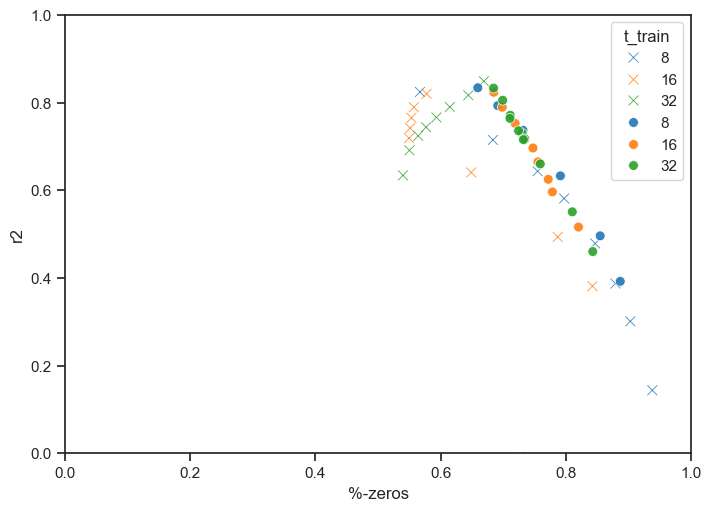

In [29]:
fig, ax = create_figure(1, 1, (7, 5), 'all', 'all')
# sns.scatterplot(data=df_old, x='%-zeros', y='r2', color='dimgray', s=100, alpha=0.7, ax=ax)
sns.scatterplot(data=df_old, x='%-zeros', y='r2', hue='seq_len', palette='tab10', marker='x', s=50, alpha=0.9, ax=ax)
sns.scatterplot(data=df_new, x='%-zeros', y='r2', hue='t_train', palette='tab10', marker='o', s=50, alpha=0.9, ax=ax)
ax.set(ylim=(0, 1), xlim=(0, 1))
plt.show()

<Axes: xlabel='%-zeros', ylabel='r2'>

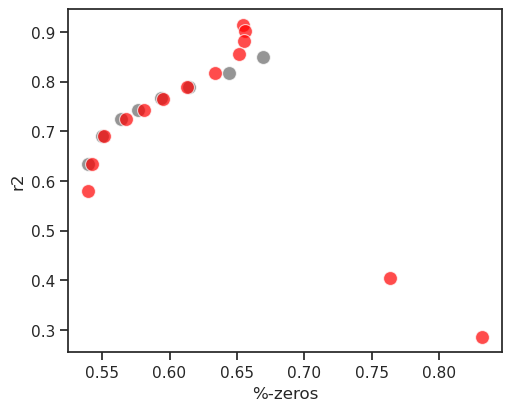

In [17]:
df_old = df_old.sort_values(by='distance')
df_new = df_new.sort_values(by='distance')

In [18]:
df_old

,type,latent_act,str_model,seq_len,kl_beta,amort,%-zeros,r2,r2_map,distance,distance_map
16,gaussian,relu,gaussian+relu,32,8.0,False,0.669052,0.848624,0.903597,0.363924,0.344703
17,gaussian,relu,gaussian+relu,32,16.0,False,0.644219,0.816526,0.879536,0.400303,0.375622
18,gaussian,relu,gaussian+relu,32,24.0,False,0.614688,0.789922,0.858864,0.438860,0.410347
19,gaussian,relu,gaussian+relu,32,32.0,False,0.593297,0.765940,0.839381,0.469246,0.437271
20,gaussian,relu,gaussian+relu,32,40.0,False,0.576717,0.743607,0.820946,0.494880,0.459597
21,gaussian,relu,gaussian+relu,32,48.0,False,0.564127,0.723872,0.804117,0.515976,0.477865
22,gaussian,relu,gaussian+relu,32,64.0,False,0.550199,0.690950,0.773914,0.545741,0.503424
23,gaussian,relu,gaussian+relu,32,96.0,False,0.539759,0.633770,0.715024,0.588172,0.541326


In [19]:
df_new

,type,latent_act,str_model,t_train,beta_outer,amort,%-zeros,r2,r2_map,distance,distance_map
0,gaussian,relu,gaussian+relu,32,8.0,False,0.651452,0.854840,0.905115,0.377567,0.361232
1,gaussian,relu,gaussian+relu,32,16.0,False,0.633609,0.817249,0.876274,0.409439,0.386718
2,gaussian,relu,gaussian+relu,32,24.0,False,0.612702,0.789113,0.854772,0.440991,0.413632
3,gaussian,relu,gaussian+relu,32,32.0,False,0.595353,0.764809,0.835681,0.468032,0.436738
4,gaussian,relu,gaussian+relu,32,40.0,False,0.580857,0.743459,0.818276,0.491421,0.456842
5,gaussian,relu,gaussian+relu,32,48.0,False,0.567896,0.723757,0.802083,0.512859,0.475273
6,gaussian,relu,gaussian+relu,32,64.0,False,0.551731,0.690117,0.772469,0.544952,0.502708
7,gaussian,relu,gaussian+relu,32,96.0,False,0.542425,0.633316,0.715561,0.586372,0.538777


## Manhattan distance

In [7]:
results_dir = pjoin(tmp_dir, 'results_2025-03')
files = [
    f for f in os.listdir(results_dir) if
    any(x in f for x in ('vH16', 'lca'))
]
files = sorted(files, key=alphanum_sort_key)

df_ratedist_manhattan = _load_df(files, metric='manhattan')
df_ratedist_manhattan.shape

100%|█████████████████████████████████████████| 175/175 [00:05<00:00, 31.63it/s]


(139, 11)

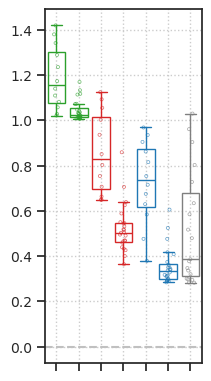

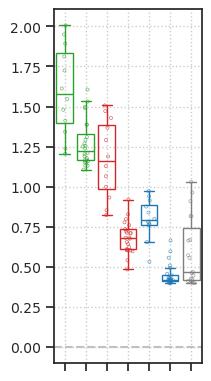

In [8]:
_ = fig_ratedist_box(df_ratedist, 'distance')
_ = fig_ratedist_box(df_ratedist_manhattan, 'distance')

### Poisson effect of beta fig

In [82]:
df_poisson = df_ratedist.loc[df_ratedist['str_model'] == 'poisson'].copy()
df_poisson['beta_ratio'] = df_poisson['kl_beta'] / df_poisson['seq_len']
df_poisson.shape

(24, 12)

In [83]:
_df = df_poisson.loc[df_poisson['seq_len'] == 16]
xticks = _df['beta_ratio'].values

In [84]:
labels = False

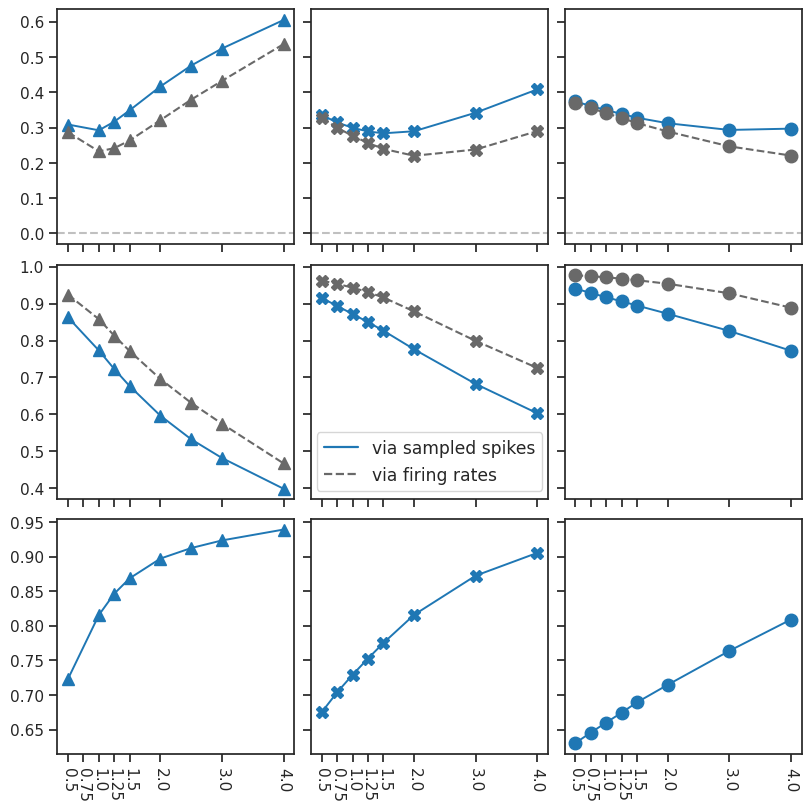

'/home/hadi/Dropbox/git/jb-progress-2025/figs/figs_2025-03/ratedist/ratedist_poisson_beta.pdf'

In [96]:
fig, axes = create_figure(3, 3, (8, 8), sharey='row', sharex='col', layout='tight')

for j, seq_len in enumerate([8, 16, 32]):
    _df = df_poisson.loc[df_poisson['seq_len'] == seq_len]
    for i, key in enumerate(['distance', 'r2', '%-zeros']):
        ax = axes[i, j]
        ax.plot(
            _df['beta_ratio'].values,
            _df[key].values,
            marker=get_marker_style(seq_len)[0],
            color=pal_models['poisson'],
            markersize=9,
            ls='-',
            lw=1.4,
        )
        key_map = f"{key}_map"
        if key_map in _df:
            ax.plot(
                _df['beta_ratio'].values,
                _df[key_map].values,
                marker=get_marker_style(seq_len)[0],
                color='dimgrey',
                markersize=9,
                ls='--',
            )
        if j == 0 and labels:
            ax.set(ylabel=key)
        if i == 2:
            ax.set(
                xticks=xticks,
                xticklabels=xticks,
            )
            ax.tick_params(axis='x', rotation=-90)
for ax in axes[0]:
    ax.axhline(0, color='silver', ls='--', zorder=0)

legend_elements = [
    matplotlib.lines.Line2D(
        [0], [0],
        label='via sampled spikes',
        color=pal_models['poisson'],
        lw=1.6,
        ls='-',
        marker=None),
    matplotlib.lines.Line2D(
        [0], [0],
        label='via firing rates',
        color='dimgrey',
        lw=1.6,
        ls='--',
        marker=None)
]
axes[1, 1].legend(
    handles=legend_elements,
    loc='lower center',
    fontsize=12.4,
)

# add_grid(axes)
save_fig('ratedist_poisson_beta.pdf', figs_dir, fig, display=True)

## Etc (adobe illustrator stuff)

In [21]:
tab10 = sns.color_palette('tab10')
tab10

[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
 (0.7372549019607844, 0.7411764705882353, 0.13333333333333333),
 (0.09019607843137255, 0.7450980392156863, 0.8117647058823529)]

In [22]:
py_color_to_latex('tab10', 'py')

\definecolor{py_0}{HTML}{1F77B4}
\definecolor{py_1}{HTML}{FF7F0E}
\definecolor{py_2}{HTML}{2CA02C}
\definecolor{py_3}{HTML}{D62728}
\definecolor{py_4}{HTML}{9467BD}
\definecolor{py_5}{HTML}{8C564B}
\definecolor{py_6}{HTML}{E377C2}
\definecolor{py_7}{HTML}{7F7F7F}
\definecolor{py_8}{HTML}{BCBD22}
\definecolor{py_9}{HTML}{17BECF}

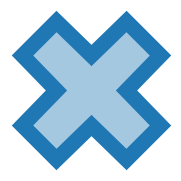

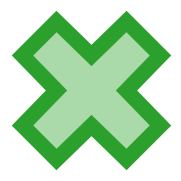

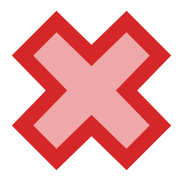

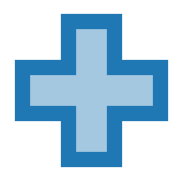

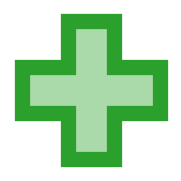

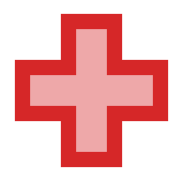

In [8]:
for marker in ['X', 'P']:
    for i in [0, 2, 3]:
        save_marker_as_pdf(marker, figs_dir, f"marker_{marker}_C{i}", face_color=tab10[i], edge_color=tab10[i])

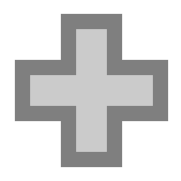

In [9]:
marker = 'P'
i = 7
save_marker_as_pdf(marker, figs_dir, f"marker_{marker}_C{i}", face_color=tab10[i], edge_color=tab10[i])